In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Set the font
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

from matplotlib.ticker import FuncFormatter

# I. Clean the ASPBI Dataset (Formal Sector)

In [138]:
filepath = 'data/aspbi_abbreviated.xlsx'
aspbi_df = pd.read_excel(filepath).T

# Clean the files
aspbi_df.columns = aspbi_df.loc['Unnamed: 0']
aspbi_df = aspbi_df.iloc[1:]
aspbi_df.index.name = 'Sector'
aspbi_df.columns.name = 'Type of Business'
aspbi_df.loc['Other'] = 0
aspbi_df.loc['O'] = 0

aspbi_df

Type of Business,Total,Micro,Small,Medium,Large
Sector,,,,,
A,155221,4163,56011,15909,79139
B,36575,257,6039,2274,28005
C,1202028,49665,246114,112004,794245
D,56455,358,7121,11696,37280
E,43386,2330,21327,6092,13638
F,286849,2480,48896,24631,210842
G,1211342,399957,583847,94377,133160
H,221493,4322,59711,17011,140449
I,363970,77929,251396,13423,21222


# II. Clean the Labor Force Survey Dataset (Formal and Informal)

In [139]:
# Open and combine the January and April files
relevant_cols = ['PUFPWGTPRV', # Final Weight Based on Projection
                 'PUFNEWEMPSTAT', # Employed (1), Unemployed (2), Not in the Labor Force (3)
                 'PUFC23_PCLASS', # Self-Employed (3)
                 'PUFC16_PKB' # Sectors
]



filepath = 'data/PHL-PSA-LFS-2022-10-PUF/LFS PUF October 2022.CSV'
oct_df = pd.read_csv(filepath)
oct_df = oct_df[relevant_cols].replace([' ', '  ', '     '], np.nan)

In [140]:
is_lf = (oct_df['PUFNEWEMPSTAT'] == '1') | (oct_df['PUFNEWEMPSTAT'] == '2')
lf_df = oct_df[is_lf].copy()
lf_df

,PUFPWGTPRV,PUFNEWEMPSTAT,PUFC23_PCLASS,PUFC16_PKB
0,242.2678,1,1,68
2,281.0598,1,1,43
4,289.8621,1,1,71
5,279.8032,1,2,84
6,276.2263,1,1,86
...,...,...,...,...
183594,193.5495,1,3,01
183595,157.5898,1,3,14
183597,193.5495,1,2,84
183598,168.3482,1,3,01


In [141]:
business_ranges = {
    "A": [(1, 3)],
    "B": [(5, 9)],
    "C": [(10, 33)],
    "D": [(35, 35)],
    "E": [(36, 39)],
    "F": [(41, 43)],
    "G": [(45, 47)],
    "H": [(49, 53)],
    "I": [(55, 56)],
    "J": [(58, 63)],
    "K": [(64, 66)],
    "L": [(68, 68)],
    "M": [(69, 75)],
    "N": [(77, 82)],
    "O": [(84, 84)],
    "P": [(85, 85)],
    "Q": [(86, 88)],
    "R": [(90, 93)],
    "S": [(94, 96)],
    "Other": [(97, 98), (99, 99)]
}

def classify_business(code):
    if pd.isna(code):
        return "Other"

    code = int(code)
    for letter, ranges in business_ranges.items():
        for lower, upper in ranges:
            if lower <= code <= upper:
                return letter
    return "Other"

lf_df.loc[:, 'Business Letter'] = lf_df['PUFC16_PKB'].map(classify_business)

In [142]:
#fig, ax = plt.subplots(figsize=(9, 6))
# all sectors
lf_sectors = lf_df.groupby('Business Letter', observed=True)['PUFPWGTPRV'].sum()


# government sector
is_gov = lf_df['PUFC23_PCLASS'] =='2'
gov_lf_df = lf_df[is_gov]
gov_lf_sectors = gov_lf_df.groupby('Business Letter', observed=True)['PUFPWGTPRV'].sum()

In [162]:
combined_df = pd.concat(
    [lf_sectors, aspbi_df['Total'], gov_lf_sectors],
    axis=1
)

combined_df.columns = ['Total', 'Formal', 'Government']

combined_df = combined_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Create the informal sector
combined_df['Informal'] = (
    combined_df['Total']
    - combined_df['Formal']
    - combined_df['Government']
)

# Prevent negative values just in case
combined_df['Informal'] = combined_df['Informal'].clip(lower=0)

In [167]:
combined_df.sum() 

Total         4.930388e+07
Formal        6.160390e+06
Government    4.174949e+06
Informal      3.898237e+07
dtype: float64

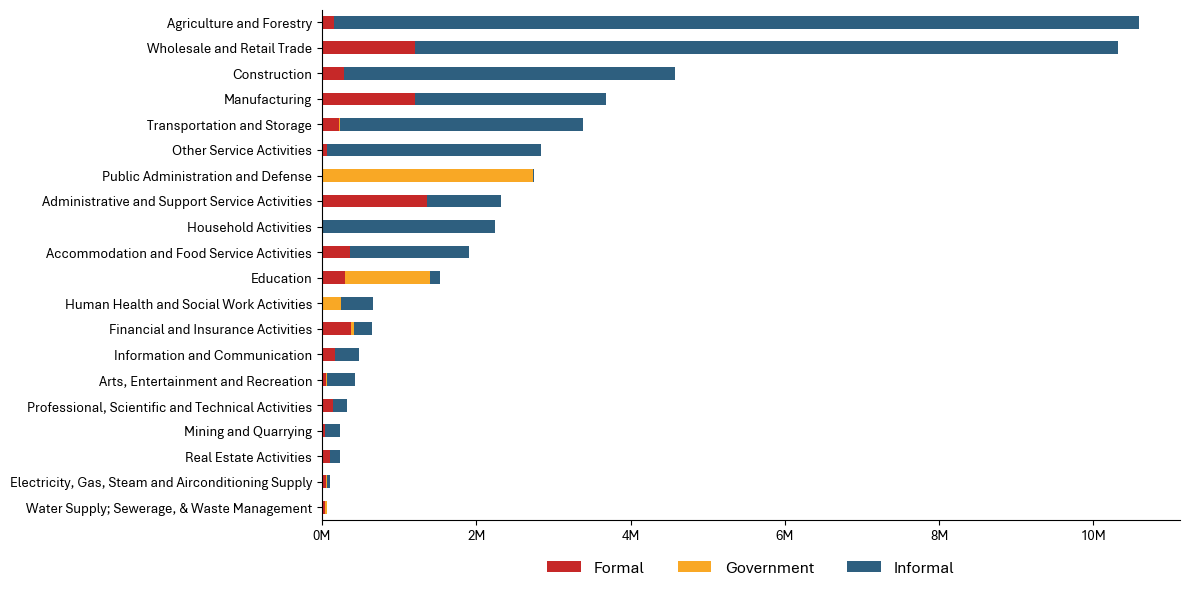

In [168]:
# Create formal names for the columns
sectors = [
    'Agriculture and Forestry',
    'Mining and Quarrying',
    'Manufacturing',
    'Electricity, Gas, Steam and Airconditioning Supply',
    'Water Supply; Sewerage, & Waste Management',
    'Construction',
    'Wholesale and Retail Trade',
    'Transportation and Storage',
    'Accommodation and Food Service Activities',
    'Information and Communication',
    'Financial and Insurance Activities',
    'Real Estate Activities',
    'Professional, Scientific and Technical Activities',
    'Administrative and Support Service Activities',
    'Public Administration and Defense',
    'Household Activities',
    'Education',
    'Human Health and Social Work Activities',
    'Arts, Entertainment and Recreation',
    'Other Service Activities',
]

combined_df.index = sectors
combined_df['Stack_Total'] = combined_df[['Formal', 'Government', 'Informal']].sum(axis=1)

# Sort descending
combined_sorted = combined_df.sort_values('Stack_Total')

fig, ax = plt.subplots(figsize=(12, 6))

# Set custom colors
colors = ['#C62828', '#F9A825', '#2E5F7F']  # Formal, Government, Informal

combined_sorted[['Formal', 'Government', 'Informal']].plot(
    kind='barh',
    stacked=True,
    color=colors,
    ax=ax
)

# Set x-axis labels in millions
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))

for tick in ax.get_xticklabels():
    tick.set_fontproperties(prop)

for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)

ax.legend(
    ['Formal', 'Government', 'Informal'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    prop=fm.FontProperties(fname=fpath, size=12)
)
plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [183]:
combined_df['Formal'].sort_values()

Household Activities                                        0
Public Administration and Defense                           0
Human Health and Social Work Activities                  7348
Mining and Quarrying                                    36575
Water Supply; Sewerage, & Waste Management              43386
Electricity, Gas, Steam and Airconditioning Supply      56455
Arts, Entertainment and Recreation                      56864
Other Service Activities                                68765
Real Estate Activities                                 104095
Professional, Scientific and Technical Activities      139732
Agriculture and Forestry                               155221
Information and Communication                          169331
Transportation and Storage                             221493
Construction                                           286849
Education                                              298370
Accommodation and Food Service Activities              363970
Financia

In [ ]:
1_364_700

1364700

In [ ]:
1_211_342